In [62]:
# import pandas
import pandas as pd 

In [63]:
# read dataset 
df = pd.read_csv('datapenumpang.csv', delimiter=';')

In [64]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
702,703,0,3,"Barbara, Miss. Saiide",female,18.0,0,1,2691,144.542,NaN,C
703,704,0,3,"Gallagher, Mr. Martin",male,25.0,0,0,36864,77.417,NaN,Q
704,705,0,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,78.542,NaN,S
705,706,0,2,"Morley, Mr. Henry Samuel (""Mr Henry Marshall"")",male,39.0,0,0,250655,26,NaN,S


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  707 non-null    int64  
 1   Survived     707 non-null    int64  
 2   Pclass       707 non-null    int64  
 3   Name         707 non-null    object 
 4   Sex          707 non-null    object 
 5   Age          562 non-null    float64
 6   SibSp        707 non-null    int64  
 7   Parch        707 non-null    int64  
 8   Ticket       707 non-null    object 
 9   Fare         707 non-null    object 
 10  Cabin        159 non-null    object 
 11  Embarked     706 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 66.4+ KB


In [66]:
# Konversi ke numerik, nilai error jadi NaN
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  707 non-null    int64  
 1   Survived     707 non-null    int64  
 2   Pclass       707 non-null    int64  
 3   Name         707 non-null    object 
 4   Sex          707 non-null    object 
 5   Age          562 non-null    float64
 6   SibSp        707 non-null    int64  
 7   Parch        707 non-null    int64  
 8   Ticket       707 non-null    object 
 9   Fare         688 non-null    float64
 10  Cabin        159 non-null    object 
 11  Embarked     706 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.4+ KB


In [68]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            145
SibSp            0
Parch            0
Ticket           0
Fare            19
Cabin          548
Embarked         1
dtype: int64

In [69]:
# Cek jumlah data duplikat
duplicate_rows = df[df.duplicated()]
jumlah_duplikat = duplicate_rows.shape[0]
print(f"Jumlah data duplikat sebelum pembersihan: {jumlah_duplikat}")

# Hapus duplikat
df_cleaned = df.drop_duplicates()
print(f"Jumlah data setelah pembersihan: {df_cleaned.shape[0]}")

Jumlah data duplikat sebelum pembersihan: 0
Jumlah data setelah pembersihan: 707


In [70]:
#Karena Atribut Cabin terlalu banyak missing valuie langsung saja di drop 1 kolom
df = df.drop(columns=['Cabin'])

In [71]:
# Isi missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

<Axes: >

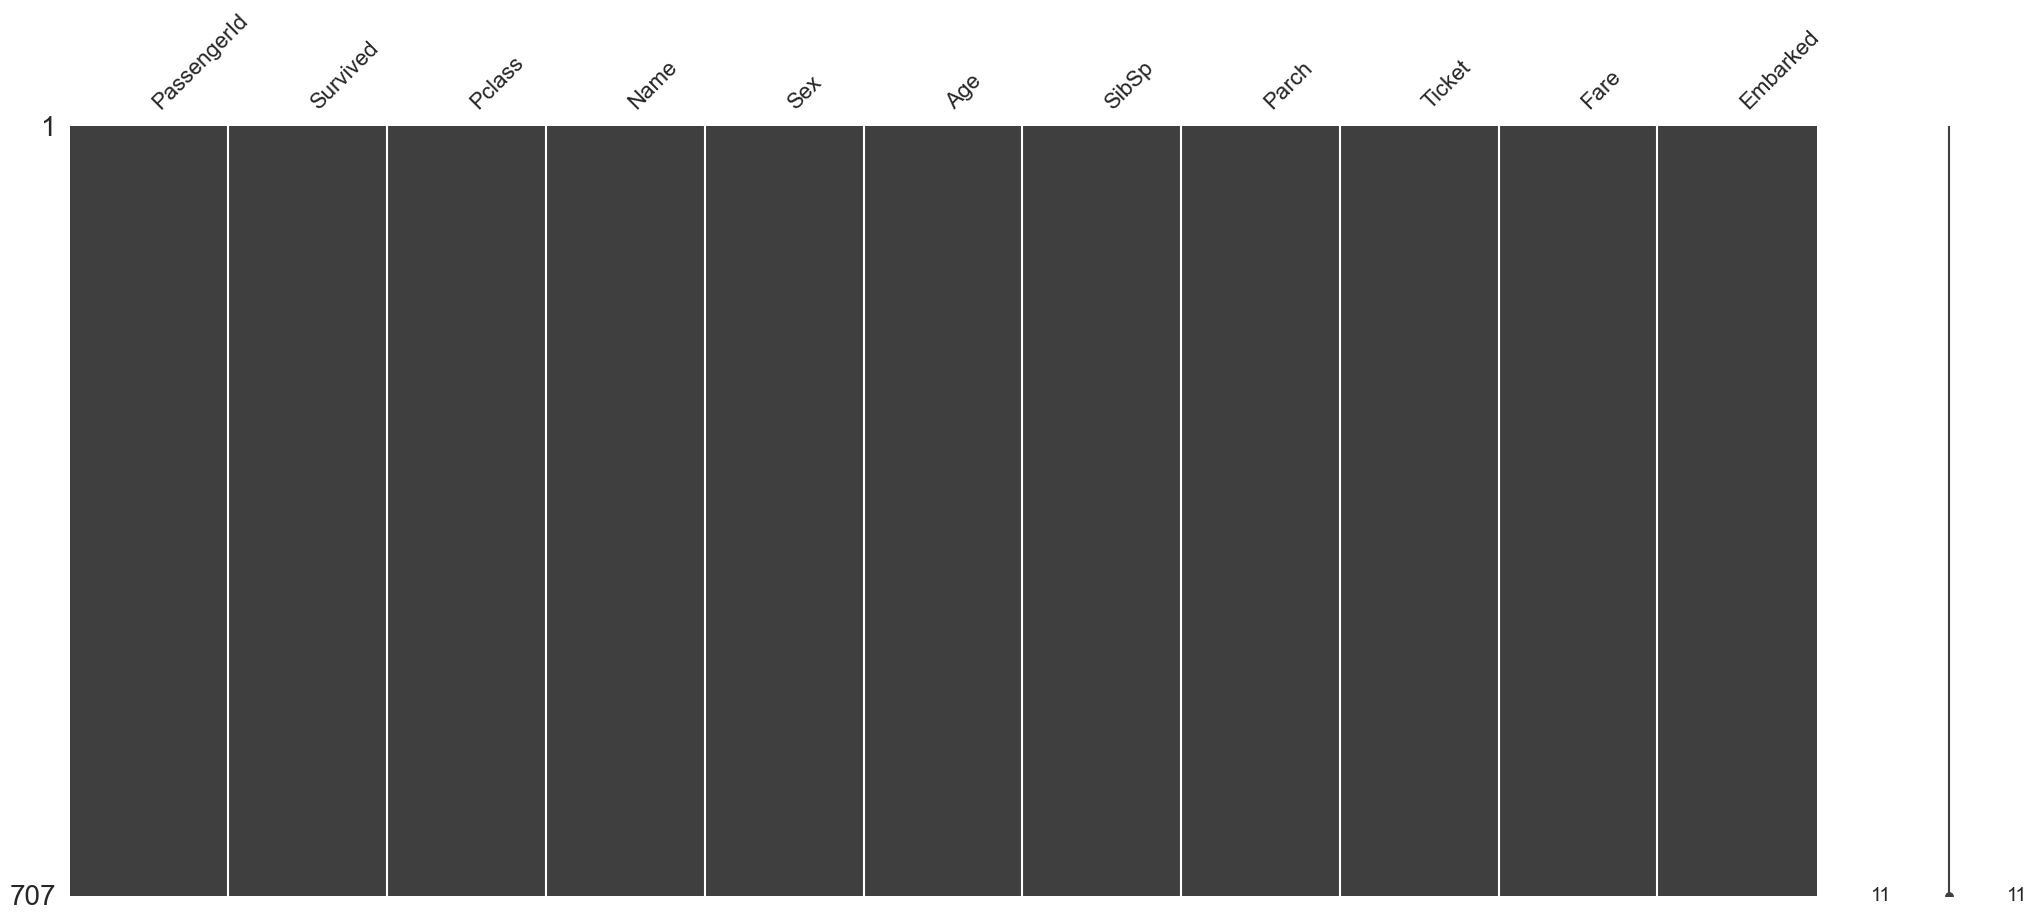

In [72]:
import missingno as msno
msno.matrix(df)

# Deteksi outlier

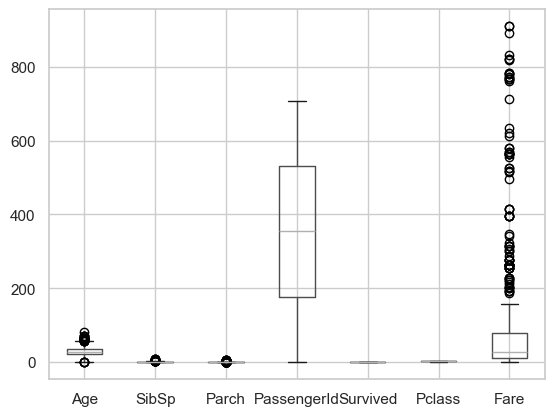

In [73]:
import matplotlib.pyplot as plt 
# find outlier
plt.Figure(figsize=(10,10))
df.boxplot(column=['Age', 'SibSp', 'Parch', 'PassengerId', 'Survived', 'Pclass','Fare'])
plt.show()

In [74]:
# Outlier & IQR 
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
Q1,Q3,IQR

(22.0, 36.0, 14.0)

In [75]:
# Batas atas dan Batas Bawah
lowwer_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lowwer_limit,upper_limit

(1.0, 57.0)

In [76]:
# menampilkan data outlier
df[(df['Age'] < lowwer_limit) | (df['Age'] > upper_limit)].shape

(34, 11)

In [77]:
# handle Outlier dengan capping
import numpy as np 
df['Age'] = np.where(df['Age'] > upper_limit,upper_limit,
                       np.where(df['Age'] < lowwer_limit,lowwer_limit,df['Age']))

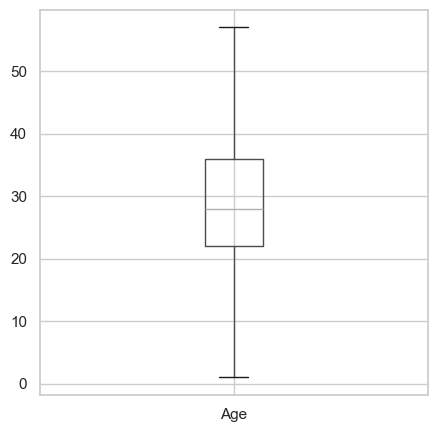

In [78]:
# cek boxplot 
plt.figure(figsize=(5,5))
df.boxplot(column=['Age'])
plt.show()

In [79]:
# Outlier & IQR 
Q1 = df['SibSp'].quantile(0.25)
Q3 = df['SibSp'].quantile(0.75)
IQR = Q3 - Q1
Q1,Q3,IQR

(0.0, 1.0, 1.0)

In [80]:
# Batas atas dan Batas Bawah
lowwer_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lowwer_limit,upper_limit

(-1.5, 2.5)

In [81]:
# menampilkan data outlier
df[(df['SibSp'] < lowwer_limit) | (df['SibSp'] > upper_limit)].shape

(37, 11)

In [82]:
# handle Outlier dengan capping
import numpy as np 
df['SibSp'] = np.where(df['SibSp'] > upper_limit,upper_limit,
                       np.where(df['SibSp'] < lowwer_limit,lowwer_limit,df['SibSp']))

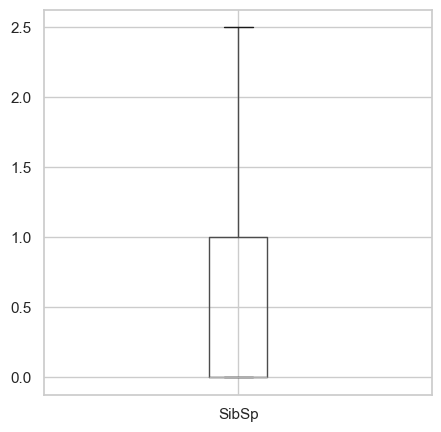

In [83]:
# cek boxplot 
plt.figure(figsize=(5,5))
df.boxplot(column=['SibSp'])
plt.show()

In [84]:
# Outlier & IQR 
Q1 = df['Parch'].quantile(0.25)
Q3 = df['Parch'].quantile(0.75)
IQR = Q3 - Q1
Q1,Q3,IQR

(0.0, 0.0, 0.0)

In [85]:
# Batas atas dan Batas Bawah
lowwer_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lowwer_limit,upper_limit

(0.0, 0.0)

In [86]:
# menampilkan data outlier
df[(df['Parch'] < lowwer_limit) | (df['Parch'] > upper_limit)].shape

(168, 11)

In [87]:
# handle Outlier dengan capping
import numpy as np 
df['Parch'] = np.where(df['Parch'] > upper_limit,upper_limit,
                       np.where(df['Parch'] < lowwer_limit,lowwer_limit,df['Parch']))

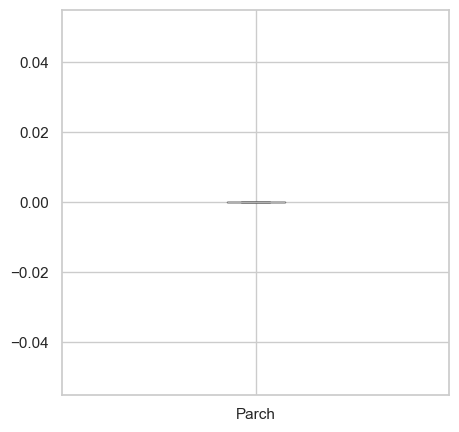

In [88]:
# cek boxplot 
plt.figure(figsize=(5,5))
df.boxplot(column=['Parch'])
plt.show()

In [89]:
# Outlier & IQR 
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
Q1,Q3,IQR

(10.5, 78.958, 68.458)

In [90]:
# Batas atas dan Batas Bawah
lowwer_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lowwer_limit,upper_limit

(-92.187, 181.64499999999998)

In [91]:
# menampilkan data outlier
df[(df['Fare'] < lowwer_limit) | (df['Fare'] > upper_limit)].shape

(90, 11)

In [92]:
# handle Outlier dengan capping
import numpy as np 
df['Fare'] = np.where(df['Fare'] > upper_limit,upper_limit,
                       np.where(df['Fare'] < lowwer_limit,lowwer_limit,df['Fare']))

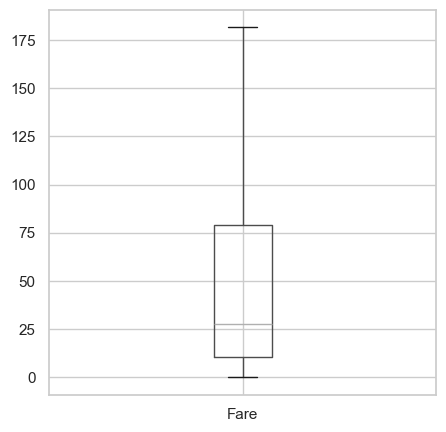

In [93]:
# cek boxplot 
plt.figure(figsize=(5,5))
df.boxplot(column=['Fare'])
plt.show()

In [94]:
df.shape

(707, 11)

# Analis Pola Keselamatan 

In [95]:
# Encode kolom 'Sex' dan 'Embarked'
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Name', 'Ticket'], drop_first=True)


In [96]:
X = df.drop('Survived', axis=1)   # fitur
y = df['Survived']                # label


In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [98]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [99]:
# Prediksi pada data uji
y_pred = model.predict(X_test)


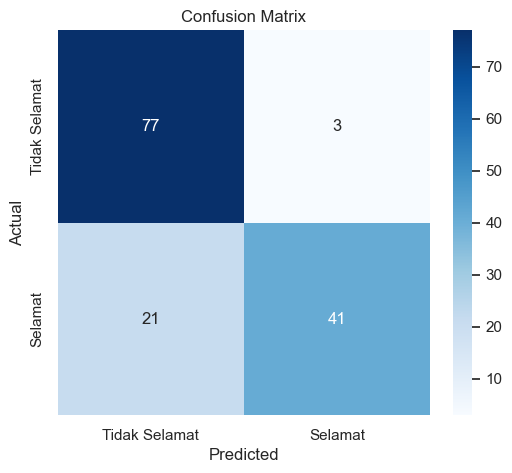

In [100]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix dengan heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Selamat', 'Selamat'], yticklabels=['Tidak Selamat', 'Selamat'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [102]:
# Menampilkan classification report
report = classification_report(y_test, y_pred, target_names=['Tidak Selamat', 'Selamat'])
print(report)


               precision    recall  f1-score   support

Tidak Selamat       0.79      0.96      0.87        80
      Selamat       0.93      0.66      0.77        62

     accuracy                           0.83       142
    macro avg       0.86      0.81      0.82       142
 weighted avg       0.85      0.83      0.83       142

